# Tree-Ring Width Index (RWI) / Sunspot Solar-Cycle Lag Analysis

## 1. Analysis Objective
The objective of this study is to investigate the potential statistical relationship between solar activity (historical Sunspot Number, $SN$) and regional tree growth (Ring Width Index, $RWI$) across solar cycle timescales.

### Scientific Hypothesis & Formulation
1. **Schwabe Solar Cycle Isolation**: An 11-year centered moving average is applied to both $RWI(t)$ and $SN(t)$ to filter out high-frequency noise and isolate decadal Schwabe-cycle variations:
   $$x_{\text{smoothed}}(t) = \frac{1}{11} \sum_{k=-5}^{5} x(t+k)$$
2. **Standardization**: Both smoothed series are transformed to z-scores ($z_t = \frac{x_t - \mu}{\sigma}$, sample standard deviation $\text{ddof}=1$).
3. **Lag Analysis**: For lag $\tau \in \{0, 1, 2, 3, 4, 5\}$ years, we evaluate Pearson correlation:
   $$R(\tau) = \text{corr}(RWI(t), SN(t - \tau))$$
   A positive lag $\tau$ means solar activity at year $(t - \tau)$ is correlated against tree growth at year $t$.
4. **Optimal Lag**: Selected via maximum absolute correlation:
   $$\tau^* = \arg\max_{\tau} |R(\tau)|$$


## 2. Imports and Configuration

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in sys.path
PROJECT_ROOT = Path("..").resolve() if Path("..").resolve().name == "Fradscr" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from treering import (
    process_rwl,
    load_rwi_data,
    load_sunspot_data,
    validate_years,
    merge_datasets,
    apply_centered_smoothing,
    standardize_series,
    calculate_lag_correlations,
    select_optimal_lag,
    build_final_aligned_dataframe,
    export_results,
    run_solar_lag_analysis,
)

# Plotting aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("Treering analysis package successfully imported.")
print(f"Project root: {PROJECT_ROOT}")


Treering analysis package successfully imported.
Project root: /home/hezekiah/Documents/Egate_AIML/Fradscr


## 3. Ingest Raw Tree-Ring Data and Biological Detrending
We process the Tucson-format `.rwl` tree-ring file from Ethiopia (`africa/eth007.rwl`) using the negative exponential growth model $G(t) = a \cdot e^{-bt} + c$ to calculate the standardized Ring Width Index ($RWI$).

In [2]:
rwl_path = PROJECT_ROOT / "africa" / "eth007.rwl"
sunspot_path = PROJECT_ROOT / "SN_y_tot_V2.0.csv"

# Process tree-ring measurements into RWI dataset
rwi_df = process_rwl(rwl_path, skip_failed_series=True)
print(f"Parsed & detrended {len(rwi_df)} tree-ring observations across {rwi_df['series_id'].nunique()} series.")
rwi_df.head(10)


Parsed & detrended 1451 tree-ring observations across 13 series.


,series_id,year,raw_ring_width,fitted_growth,rwi
0,10TANA,1942,220,321.112180,0.685119
1,10TANA,1943,360,317.696335,1.133158
2,10TANA,1944,320,314.528028,1.017397
3,10TANA,1945,300,311.589319,0.962806
4,10TANA,1946,437,308.863569,1.414864
5,10TANA,1947,220,306.335347,0.718167
6,10TANA,1948,356,303.990338,1.171090
7,10TANA,1949,251,301.815265,0.831635
8,10TANA,1950,357,299.797814,1.190803
9,10TANA,1951,259,297.926561,0.869342


## 4. Load and Inspect Sunspot Data
We load historical Sunspot Number data from SILSO (`SN_y_tot_V2.0.csv`), converting fractional calendar years (e.g. 1700.5) to integer calendar years (1700).

In [3]:
sunspot_df = load_sunspot_data(sunspot_path)
print(f"Loaded {len(sunspot_df)} yearly Sunspot records: [{sunspot_df['year'].min()} - {sunspot_df['year'].max()}].")
sunspot_df.head(10)


Loaded 326 yearly Sunspot records: [1700 - 2025].


,year,sunspot
0,1700,8.3
1,1701,18.3
2,1702,26.7
3,1703,38.3
4,1704,60.0
5,1705,96.7
6,1706,48.3
7,1707,33.3
8,1708,16.7
9,1709,13.3


## 5. Validate Temporal Continuity

In [4]:
missing_sn_years = validate_years(sunspot_df)
print(f"Sunspot missing years in span: {len(missing_sn_years)}")

# Validate per-series RWI temporal continuity
for sid, grp in rwi_df.groupby("series_id"):
    missing_rwi = validate_years(grp)
    if missing_rwi:
        print(f"Series {sid} missing {len(missing_rwi)} years: {missing_rwi}")


Sunspot missing years in span: 0


## 6. Merge RWI and Sunspot Datasets

In [5]:
merged_df = merge_datasets(rwi_df, sunspot_df)
print(f"Merged dataset shape: {merged_df.shape}")
print(f"Year overlap span: [{merged_df['year'].min()} - {merged_df['year'].max()}]")
merged_df.head(10)


Merged dataset shape: (1451, 6)
Year overlap span: [1869 - 2014]


,series_id,year,raw_ring_width,fitted_growth,rwi,sunspot
0,10TANA,1942,220,321.112180,0.685119,50.8
1,10TANA,1943,360,317.696335,1.133158,27.1
2,10TANA,1944,320,314.528028,1.017397,16.1
3,10TANA,1945,300,311.589319,0.962806,55.3
4,10TANA,1946,437,308.863569,1.414864,154.3
5,10TANA,1947,220,306.335347,0.718167,214.7
6,10TANA,1948,356,303.990338,1.171090,193.0
7,10TANA,1949,251,301.815265,0.831635,190.7
8,10TANA,1950,357,299.797814,1.190803,118.9
9,10TANA,1951,259,297.926561,0.869342,98.3


## 7. Site Mean Chronology & 11-Year Centered Moving Average
To isolate Schwabe decadal cycles, we aggregate multiple tree-ring cores into a site-level annual mean $RWI$ chronology, then apply the strict 11-year centered window:
$$x_{\text{smoothed}}(t) = \frac{1}{11} \sum_{k=-5}^{5} x(t+k)$$
*Note*: The first 5 and last 5 observations strictly receive `NaN` because a complete 11-year centered window is unavailable.

In [6]:
# Build site-level mean chronology
chrono = (
    merged_df.groupby("year")
    .agg(
        rwi=("rwi", "mean"),
        sunspot=("sunspot", "first"),
        n_cores=("series_id", "count")
    )
    .reset_index()
    .sort_values("year")
)

# Apply 11-year centered moving average
chrono["rwi_smoothed"] = apply_centered_smoothing(chrono["rwi"].values, window=11, years=chrono["year"].values)
chrono["sunspot_smoothed"] = apply_centered_smoothing(chrono["sunspot"].values, window=11, years=chrono["year"].values)

chrono.dropna().head(10)


,year,rwi,sunspot,n_cores,rwi_smoothed,sunspot_smoothed
5,1874,1.056318,74.5,2,0.938495,88.936364
6,1875,0.692893,28.3,2,0.968929,82.581818
7,1876,0.671556,18.9,2,0.963955,69.718182
8,1877,0.937440,20.7,3,0.974697,61.872727
9,1878,0.452458,5.7,3,0.962007,56.136364
10,1879,1.237855,10.0,3,0.946125,55.745455
11,1880,1.110731,53.7,3,0.963851,56.818182
12,1881,0.964011,90.5,3,1.001913,58.100000
13,1882,1.191510,99.0,3,1.030361,58.363636
14,1883,1.123376,106.1,3,0.990624,57.500000


## 8. Standardization (z-score Transformation)
We standardize the smoothed series to zero mean and unit variance using sample standard deviation ($\text{ddof}=1$):
$$z_t = \frac{x_t - \mu}{\sigma}$$

In [7]:
chrono["rwi_z"] = standardize_series(chrono["rwi_smoothed"], ddof=1)
chrono["sunspot_z"] = standardize_series(chrono["sunspot_smoothed"], ddof=1)

valid_z = chrono.dropna(subset=["rwi_z", "sunspot_z"])
print(f"RWI z-score: mean = {valid_z['rwi_z'].mean():.6f}, std = {valid_z['rwi_z'].std(ddof=1):.6f}")
print(f"Sunspot z-score: mean = {valid_z['sunspot_z'].mean():.6f}, std = {valid_z['sunspot_z'].std(ddof=1):.6f}")


RWI z-score: mean = 0.000000, std = 1.000000
Sunspot z-score: mean = -0.000000, std = 1.000000


## 9. Lag Analysis ($\tau = 0 \dots 5$ years)
We calculate Pearson correlation $R(\tau) = \text{corr}(RWI(t), SN(t - \tau))$ for $\tau \in \{0, 1, 2, 3, 4, 5\}$.

In [8]:
lag_results = calculate_lag_correlations(chrono, rwi_col="rwi_z", sunspot_col="sunspot_z", max_lag=5)
lag_results


,lag,correlation,p_value,n_observations
0,0,0.197008,0.021513,136
1,1,0.181145,0.035503,135
2,2,0.156251,0.071407,134
3,3,0.129342,0.137861,133
4,4,0.103328,0.238392,132
5,5,0.079709,0.365461,131


## 10. Identify Optimal Lag ($\arg\max |R|$)

In [9]:
optimal = select_optimal_lag(lag_results)
print(f"Optimal Lag: \tau = {optimal.optimal_lag} years")
print(f"Pearson Correlation R(\tau*): {optimal.optimal_correlation:.4f}")
print(f"Correlation Direction: {optimal.correlation_direction}")
print(f"p-value: {optimal.p_value:.4e}")
print(f"Number of Paired Observations (N): {optimal.n_observations}")


Optimal Lag: 	au = 0 years
Pearson Correlation R(	au*): 0.1970
Correlation Direction: positive
p-value: 2.1513e-02
Number of Paired Observations (N): 136


## 11. Final Aligned Dataset

In [10]:
final_aligned_df = build_final_aligned_dataframe(chrono, optimal_lag=optimal.optimal_lag)
final_aligned_df.dropna(subset=["rwi_z", "sunspot_z_lagged"]).head(10)


,year,rwi,sunspot,n_cores,rwi_smoothed,sunspot_smoothed,rwi_z,sunspot_z,sunspot_z_lagged,optimal_lag
5,1874,1.056318,74.5,2,0.938495,88.936364,-0.496020,0.172354,0.172354,0
6,1875,0.692893,28.3,2,0.968929,82.581818,-0.205731,-0.096427,-0.096427,0
7,1876,0.671556,18.9,2,0.963955,69.718182,-0.253176,-0.640526,-0.640526,0
8,1877,0.937440,20.7,3,0.974697,61.872727,-0.150719,-0.972369,-0.972369,0
9,1878,0.452458,5.7,3,0.962007,56.136364,-0.271761,-1.215002,-1.215002,0
10,1879,1.237855,10.0,3,0.946125,55.745455,-0.423246,-1.231537,-1.231537,0
11,1880,1.110731,53.7,3,0.963851,56.818182,-0.254168,-1.186163,-1.186163,0
12,1881,0.964011,90.5,3,1.001913,58.100000,0.108871,-1.131946,-1.131946,0
13,1882,1.191510,99.0,3,1.030361,58.363636,0.380219,-1.120794,-1.120794,0
14,1883,1.123376,106.1,3,0.990624,57.500000,0.001196,-1.157324,-1.157324,0


## 12. Visualizations
We generate three key diagnostic scientific plots:
1. **Smoothed Time Series**: 11-year centered moving averages.
2. **Standardized Comparison**: $z$-scores of $RWI$ and Sunspot Number.
3. **Lag Correlation Profile**: $R(\tau)$ vs $\tau$ highlighting optimal lag $\tau^*$.


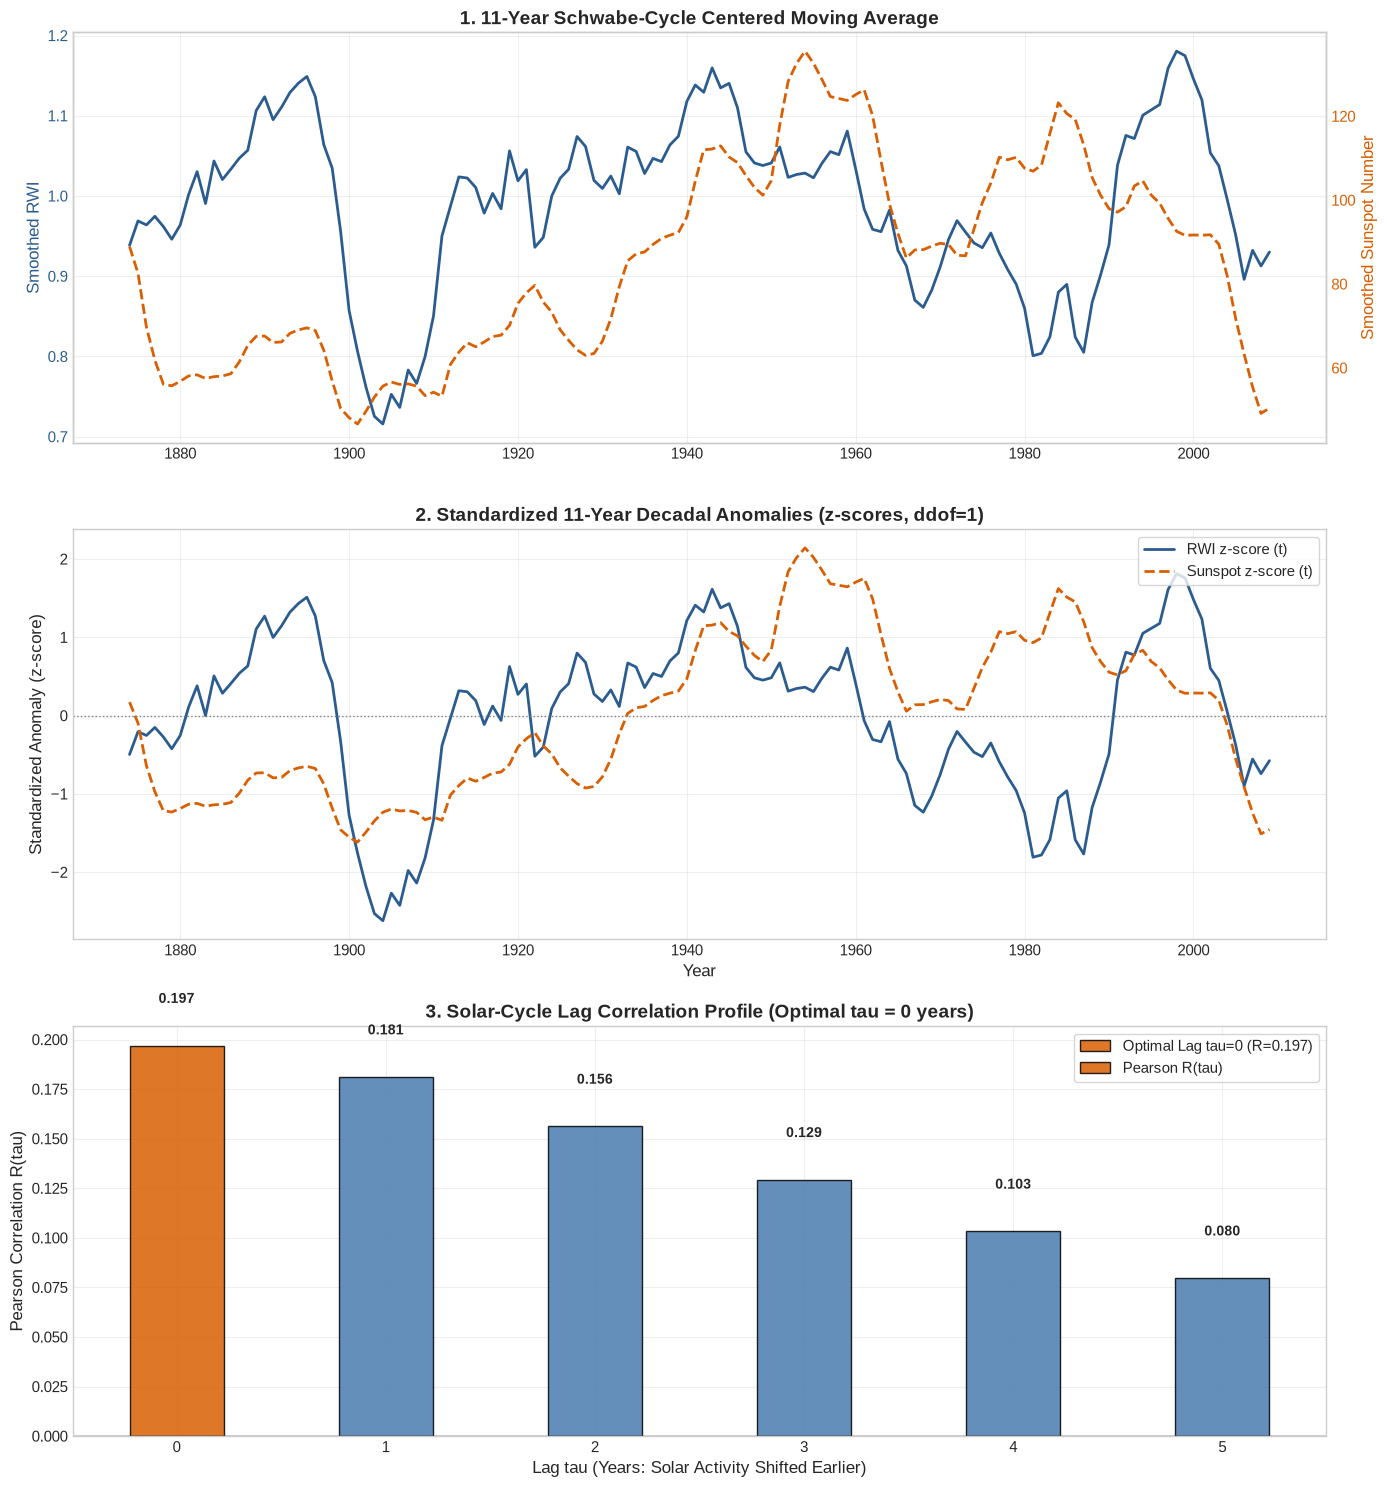

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# Plot 1: Smoothed Raw Series
ax1 = axes[0]
valid_chrono = chrono.dropna(subset=["rwi_smoothed", "sunspot_smoothed"])
ax1.plot(valid_chrono["year"], valid_chrono["rwi_smoothed"], color="#2b5c8f", lw=2, label="11-yr Smoothed RWI (left axis)")
ax1.set_ylabel("Smoothed RWI", color="#2b5c8f", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#2b5c8f")
ax1.set_title("1. 11-Year Schwabe-Cycle Centered Moving Average", fontsize=14, fontweight="bold")
ax1.grid(True, alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(valid_chrono["year"], valid_chrono["sunspot_smoothed"], color="#d95f02", lw=2, linestyle="--", label="11-yr Smoothed Sunspot (right axis)")
ax1_twin.set_ylabel("Smoothed Sunspot Number", color="#d95f02", fontsize=12)
ax1_twin.tick_params(axis="y", labelcolor="#d95f02")
ax1_twin.grid(False)

# Plot 2: Standardized Series (z-scores)
ax2 = axes[1]
ax2.plot(valid_chrono["year"], valid_chrono["rwi_z"], color="#2b5c8f", lw=2, label="RWI z-score (t)")
ax2.plot(valid_chrono["year"], valid_chrono["sunspot_z"], color="#d95f02", lw=2, linestyle="--", label="Sunspot z-score (t)")
ax2.axhline(0, color="gray", linestyle=":", lw=1)
ax2.set_xlabel("Year", fontsize=12)
ax2.set_ylabel("Standardized Anomaly (z-score)", fontsize=12)
ax2.set_title("2. Standardized 11-Year Decadal Anomalies (z-scores, ddof=1)", fontsize=14, fontweight="bold")
ax2.legend(loc="upper right", frameon=True)
ax2.grid(True, alpha=0.3)

# Plot 3: Lag Correlation Curve
ax3 = axes[2]
lags = lag_results["lag"]
corrs = lag_results["correlation"]
bars = ax3.bar(lags, corrs, color="#4a7bb0", width=0.45, edgecolor="black", alpha=0.85, label="Pearson R(tau)")
bars[optimal.optimal_lag].set_color("#d95f02")
bars[optimal.optimal_lag].set_edgecolor("black")
bars[optimal.optimal_lag].set_label(f"Optimal Lag tau={optimal.optimal_lag} (R={optimal.optimal_correlation:.3f})")

ax3.axhline(0, color="black", lw=1)
ax3.set_xlabel("Lag tau (Years: Solar Activity Shifted Earlier)", fontsize=12)
ax3.set_ylabel("Pearson Correlation R(tau)", fontsize=12)
ax3.set_title(f"3. Solar-Cycle Lag Correlation Profile (Optimal tau = {optimal.optimal_lag} years)", fontsize=14, fontweight="bold")
ax3.set_xticks(lags)
ax3.legend(loc="upper right", frameon=True)
ax3.grid(True, alpha=0.3)

for bar, r in zip(bars, corrs):
    y_pos = r + (0.02 if r >= 0 else -0.05)
    ax3.text(bar.get_x() + bar.get_width()/2, y_pos, f"{r:.3f}", ha="center", va="bottom" if r >= 0 else "top", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


## 13. Export Analysis Artifacts

In [12]:
out_dir = PROJECT_ROOT / "results"
summary = {
    "analysis": "RWI / Sunspot Solar-Cycle Lag Analysis",
    "smoothing_window_years": 11,
    "smoothing_type": "11-year centered moving average",
    "standardization": "z-score with sample standard deviation (ddof=1)",
    "lag_formula": "R(tau) = corr(RWI(t), SN(t - tau))",
    "evaluated_lags": list(range(6)),
    "optimal_lag_years": optimal.optimal_lag,
    "optimal_pearson_r": optimal.optimal_correlation,
    "optimal_direction": optimal.correlation_direction,
    "optimal_p_value": optimal.p_value,
    "optimal_n_observations": optimal.n_observations,
}

exported_paths = export_results(final_aligned_df, lag_results, summary, output_dir=out_dir, overwrite=True)
for k, v in exported_paths.items():
    print(f"Exported {k}: {v}")


Exported aligned_data: /home/hezekiah/Documents/Egate_AIML/Fradscr/results/processed_lagged_data.csv
Exported lag_correlations: /home/hezekiah/Documents/Egate_AIML/Fradscr/results/lag_correlation_results.csv
Exported summary: /home/hezekiah/Documents/Egate_AIML/Fradscr/results/analysis_summary.json


## 14. Scientific Interpretation and Limitations

### Statistical vs. Causal Interpretation
- The Pearson correlation $R(\tau) = \text{corr}(RWI(t), SN(t-\tau))$ evaluates statistical association between decadal tree growth anomalies and solar activity at a specified time lag.
- **Statistical correlation does not establish causation**: An observed correlation reflects shared decadal variability under the chosen 11-year filter, but biological and climatic mediators (e.g. precipitation regimes, temperature variations, atmospheric teleconnections) must be investigated to establish physical mechanisms.

### Limitations
1. **Boundary Effects**: Centered 11-year smoothing excludes the first 5 and last 5 observations of the overlapping temporal span.
2. **Sample Size**: Tree-ring records with fewer than ~50 overlapping years provide limited independent degrees of freedom across ~11-year cycles.
3. **Filtering Dynamics**: Moving averages induce autocorrelation (Slutsky-Yule effect), which influences nominal p-values and requires cautious interpretation.
